# Breast Cancer Histopathology Classifier

This project uses histopathology data from the [Breast Cancer Wisconsin (Diagnostic) Data Set](https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data/data) to predict whether breast cell samples are malignant or benign.

## About the Data

Each sample is a digitized image of a fine needle aspirate (FNA) of a breast mass. The cell nuclei of each sample are examined and the mean, standard error, and worst/largest (mean of the 3 largest values) of each characteristic is recorded, leading to 30 features for 10 characteristics:
- radius (mean of distances from center to points on the perimeter)
    - cannot be negative or 0
    - Malignant cells have larger radius than normal.
- texture (standard deviation of gray-scale values)
    - can be 0 but not negative
    - if SD of gray-scale values is low, the nucleus appears smooth b/c chromatin is evenly dispersed, which is typical of normal, healthy, benign cells.
    - if high, nucleus looks grainy or blotchy, indicating uneven clumping and structural irregularities, which may indicate malignancy.
- perimeter
    - cell nucleus with irregular, large perimeter indicates malignancy.
    - cannot be 0 or negative
- area
    - enlarged area indicates malignancy
    - cannot be 0 or negative
- smoothness (local variation in radius lengths)
    - 0 means totally smooth, negative values not possible
    - the less smooth it is, the more likely it's malignant
- compactness (perimeter^2 / area - 1.0)
    - higher compactness indicates malignancy
    - cannot be 0 or negative
- concavity (severity of concave portions of the contour)
    - high degree of concavity is typically associated with malignant cells
    - can be 0 but not negative
- concave points (number of concave portions of the contour)
    - higher number typically indicates malignancy
    - can be 0 but not negative
- symmetry (computed by measuring the major axis through the center and then measuring the length difference between lines perpendicular to the major axis to the cell boundary in both directions.)
    - asymmetry indicates malignancy
    - cannot be negative
- fractal dimension ("coastline approximation" - 1)
    - higher fractal dimension typically indicates  malignancy b/c it reflects highly chaotic, jagged boundaries and complex, uneven chromatin arrangements
    - cannot be 0 or negative

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from scipy.stats import mannwhitneyu

## Prepping Data

### Load data

In [2]:
df = pd.read_csv('data.csv')
df = df.drop('Unnamed: 32', axis=1)  # there is an unnamed 32nd column with all NaN, so we remove that
df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


### Check for missing values, duplicates, if all IDs are unique

In [ ]:
df.info()  # result: no missing values

print('\nDuplicates:', df.duplicated().sum())  # result: no duplicates

# check if all ids are unique
unique_id = df['id'].is_unique
print('\nUnique IDs:', unique_id)

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

### Check for garbage values

Features are not standardized or scaled, so garbage values (e.g. 0s or negatives that are not possible) may be present and must be removed.

In [ ]:
features = df.loc[:, 'radius_mean':'fractal_dimension_mean']
any_neg = features.columns[(features < 0).any()].tolist()
any_nil = features.columns[(features == 0).any()].tolist()
print(any_neg)  # result: no negative values
print(any_nil)  # only concavity_mean and concave points_mean columns have 0 as values, which are allowed

# so no garbage values

[]
['concavity_mean', 'concave points_mean']


## Exploratory Data Analysis

Can this data actually be used to predict whether cells are malignant or benign? How do we use this data to predict that? Do the features (means and worsts) actually distinguish benign cells from malignant cells?

### Changing Diagnosis Label

In [3]:
df['diagnosis'] = df['diagnosis'].replace({'M': 'Malignant', 'B': 'Benign'})
df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,Malignant,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,Malignant,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,Malignant,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,Malignant,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,Malignant,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,Malignant,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,Malignant,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,Malignant,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,Malignant,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


### Heatmap of Features

Which features are redundant? (We don't wanna include redundant features in the model because redundant features will exert too much influence over the model's results, can cause overfitting on small datasets such as this, and slows down the model.)

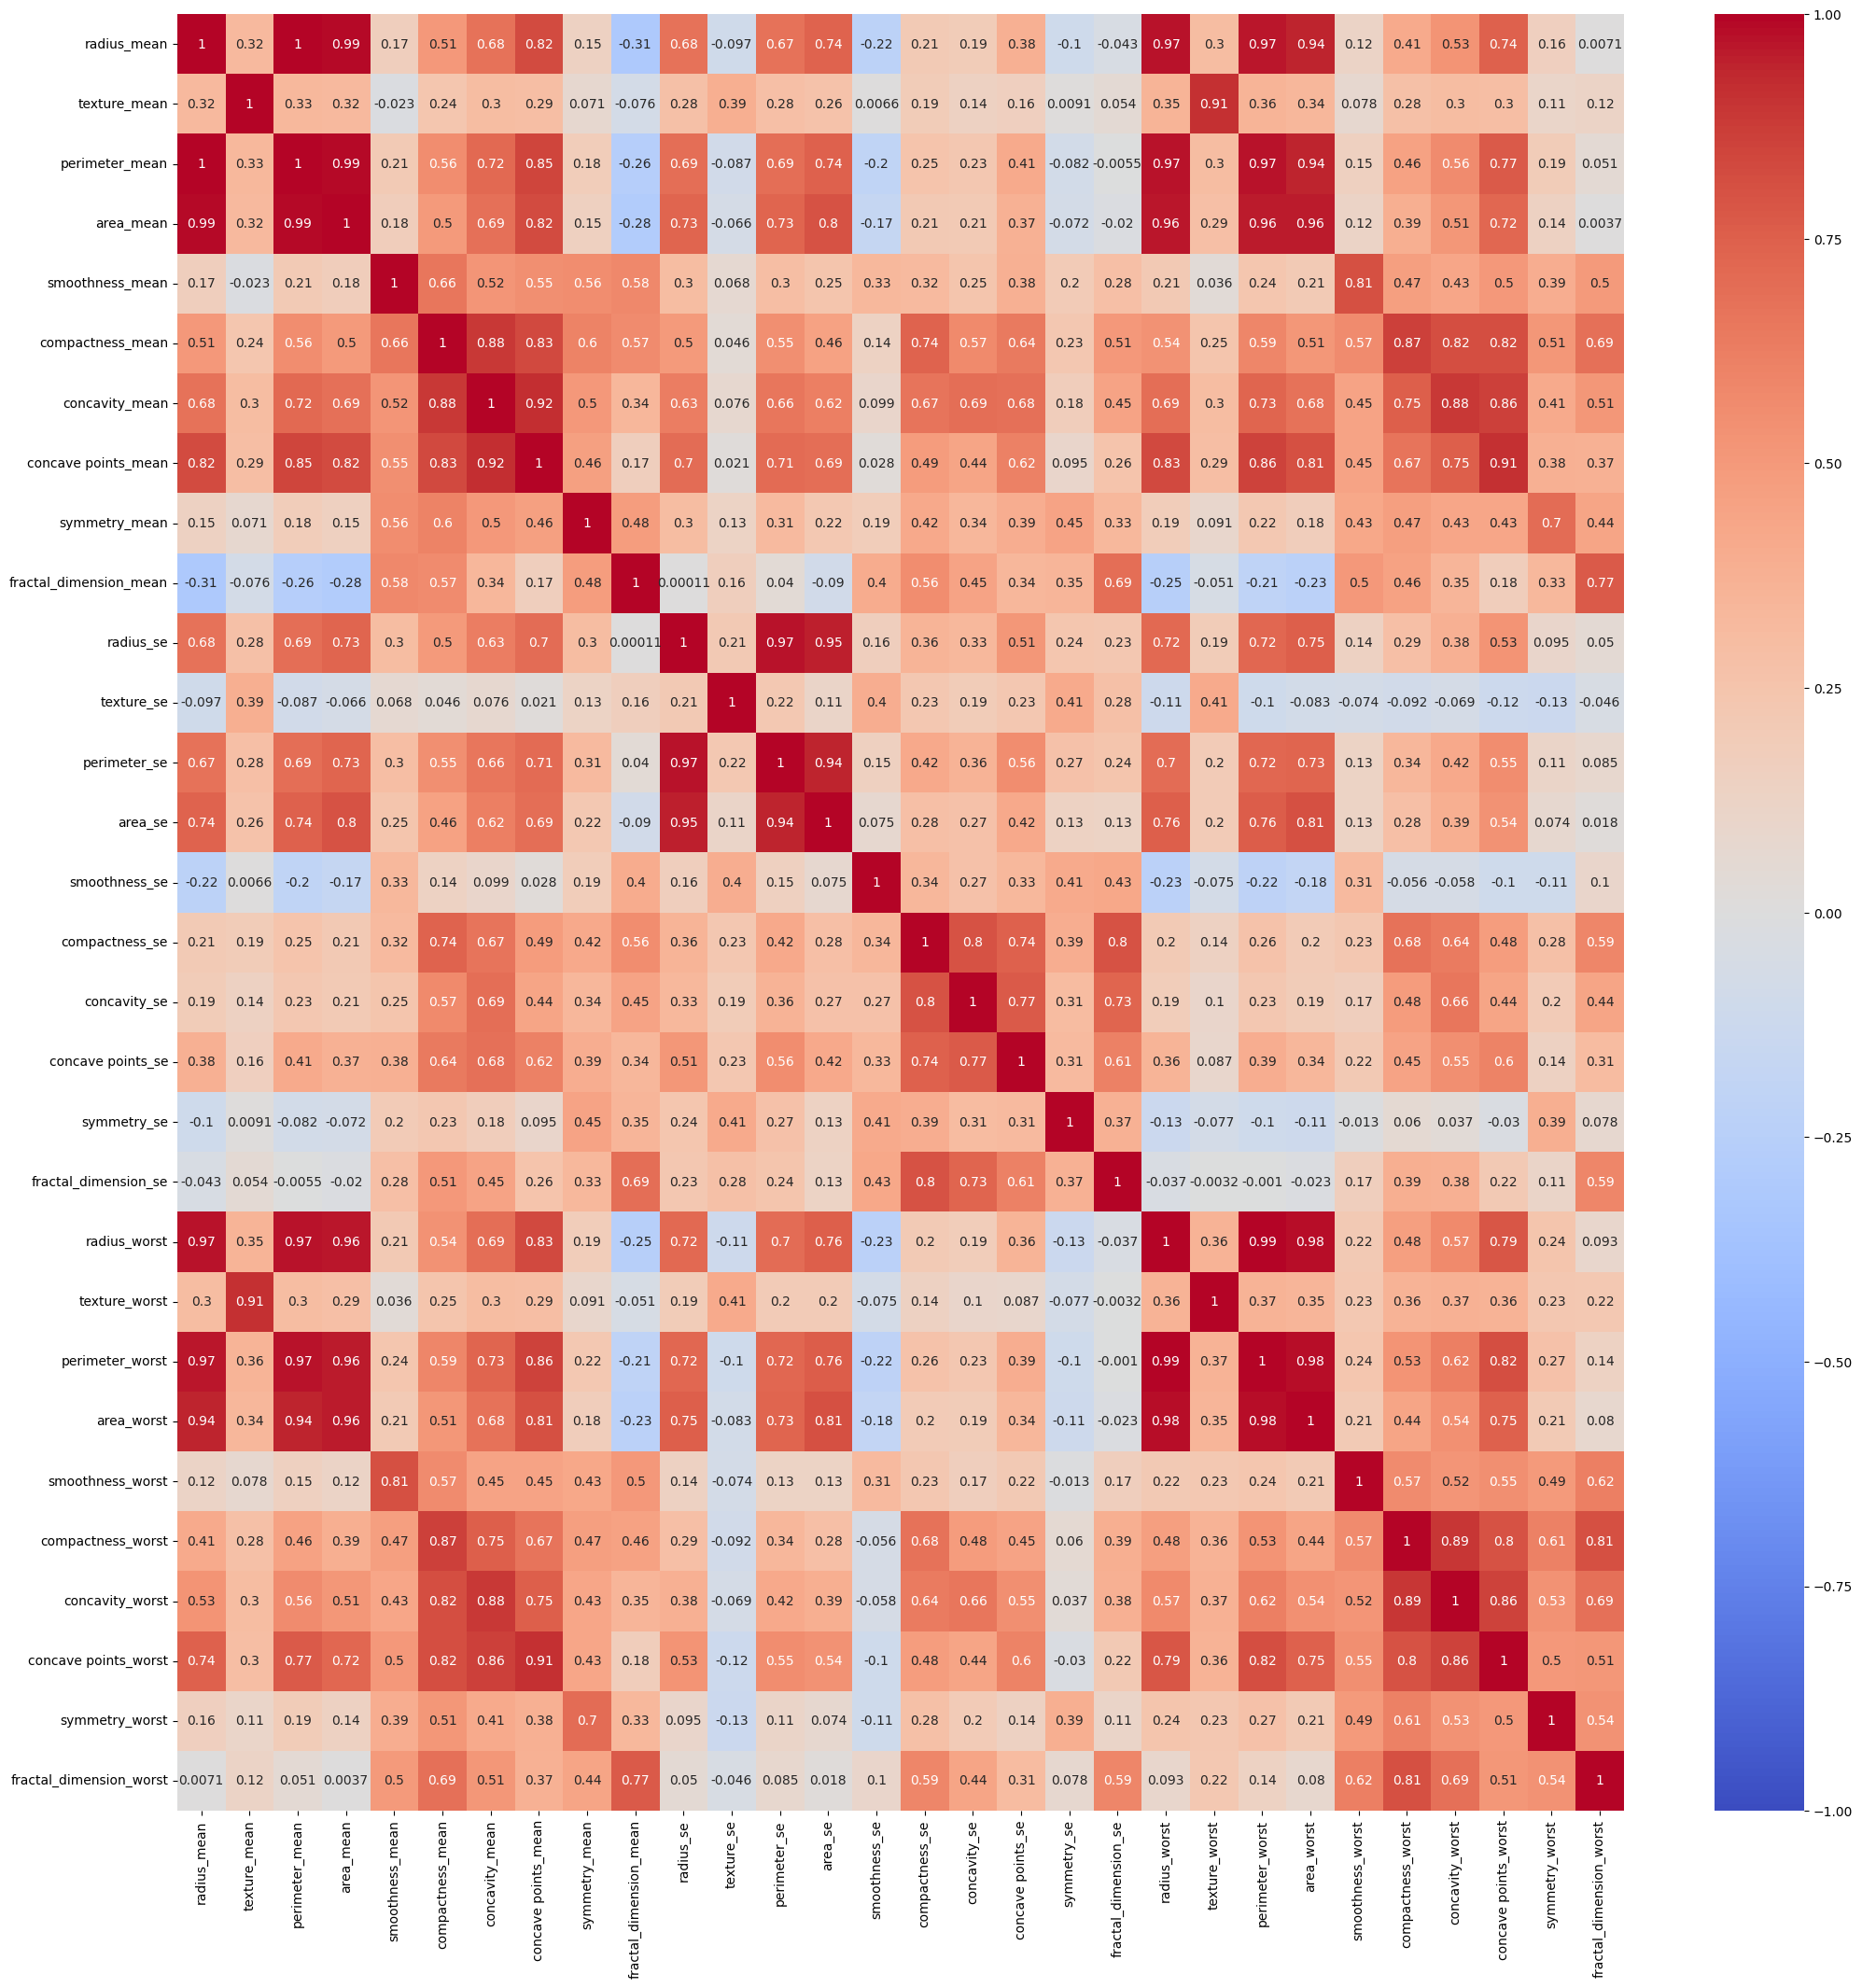

--- Features with Correlation Greater Than 0.9 ---
radius_mean <---> perimeter_mean : (r = 0.998)
radius_mean <---> area_mean : (r = 0.987)
radius_mean <---> radius_worst : (r = 0.970)
radius_mean <---> perimeter_worst : (r = 0.965)
radius_mean <---> area_worst : (r = 0.941)
texture_mean <---> texture_worst : (r = 0.912)
perimeter_mean <---> area_mean : (r = 0.987)
perimeter_mean <---> radius_worst : (r = 0.969)
perimeter_mean <---> perimeter_worst : (r = 0.970)
perimeter_mean <---> area_worst : (r = 0.942)
area_mean <---> radius_worst : (r = 0.963)
area_mean <---> perimeter_worst : (r = 0.959)
area_mean <---> area_worst : (r = 0.959)
concavity_mean <---> concave points_mean : (r = 0.921)
concave points_mean <---> concave points_worst : (r = 0.910)
radius_se <---> perimeter_se : (r = 0.973)
radius_se <---> area_se : (r = 0.952)
perimeter_se <---> area_se : (r = 0.938)
radius_worst <---> perimeter_worst : (r = 0.994)
radius_worst <---> area_worst : (r = 0.984)
perimeter_worst <---> area

In [4]:
df_heatmap = df.drop(columns=['id', 'diagnosis'])
corr_matrix = df_heatmap[list(df_heatmap.columns)].corr()

plt.figure(figsize=(25,25))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.show()

# print only features with correlation greater than 0.9

THRESHOLD = 0.9

# unstack corr matrix into a long list of correlation pairs (i.e. contains what you'd see in the heatmap but in list form)
unstacked_corr = corr_matrix.unstack()

# filter for pairs greater than threshold, but less than 1.0 so you don't include features that correlate with itself
high_corr_pairs = unstacked_corr[(unstacked_corr > THRESHOLD) & (unstacked_corr < 1.0)]

# print pairs
print(f"--- Features with Correlation Greater Than {THRESHOLD} ---")

# keep track of pairs we've already seen so we don't print "A vs B" AND "B vs A"
seen_pairs = set()

for (feat1, feat2), score in high_corr_pairs.items():
    # create a unique sorted key for the pair
    pair_key = tuple(sorted([feat1, feat2]))
    
    if pair_key not in seen_pairs:
        seen_pairs.add(pair_key)
        print(f"{feat1} <---> {feat2} : (r = {score:.3f})")

#### Conclusion

We only want to include:
- one of radius_mean, perimeter_mean, area_mean, radius_worst, perimeter_worst, area_worst
- one of texture_mean, texture_worst
- one of concavity_mean, concave points_mean, concave points_worst
- one of radius_se, perimeter_se, area_se

The one we choose is the one with the lowest p-value (Mann-Whitney U test) among the options.

In [5]:
MEAN_COL_NAMES = [col for col in df.columns if col.endswith('_mean')]
SE_COL_NAMES = [col for col in df.columns if col.endswith('_se')]
WORST_COL_NAMES = [col for col in df.columns if col.endswith('_worst')]

### Violin plots

Use split violin plots for each characteristic, 1 half for benign, other half for malignant. Plot means, worsts, and SEs. If the means plot shows a massive difference between benign and malignant halves, that feature can distinguish benign vs malignancy in most cases. But if a massive difference between benign and malignant halves only appears in the worsts plot, that feature can distinguish benign vs malignancy in cases that might be false negatives. Standard error tells you how uniform or diverse the cells are for a certain trait: malignant cells will have more diversity (SE > 0 and distribution is spread out) than benign cells (SE near 0 and clustered around there).

In [6]:
# create dataframe for violin plot
scaler_for_viz = StandardScaler()
characteristics_only = df.drop(columns=['diagnosis', 'id'])

df_viz_scaled = pd.DataFrame(scaler_for_viz.fit_transform(characteristics_only), columns=characteristics_only.columns)
df_viz_scaled['diagnosis'] = df['diagnosis'].values

df_viz_scaled

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,diagnosis
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015,Malignant
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190,Malignant
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391,Malignant
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010,Malignant
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100,Malignant
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,2.110995,0.721473,2.060786,2.343856,1.041842,0.219060,1.947285,2.320965,-0.312589,-0.931027,...,0.117700,1.752563,2.015301,0.378365,-0.273318,0.664512,1.629151,-1.360158,-0.709091,Malignant
565,1.704854,2.085134,1.615931,1.723842,0.102458,-0.017833,0.693043,1.263669,-0.217664,-1.058611,...,2.047399,1.421940,1.494959,-0.691230,-0.394820,0.236573,0.733827,-0.531855,-0.973978,Malignant
566,0.702284,2.045574,0.672676,0.577953,-0.840484,-0.038680,0.046588,0.105777,-0.809117,-0.895587,...,1.374854,0.579001,0.427906,-0.809587,0.350735,0.326767,0.414069,-1.104549,-0.318409,Malignant
567,1.838341,2.336457,1.982524,1.735218,1.525767,3.272144,3.296944,2.658866,2.137194,1.043695,...,2.237926,2.303601,1.653171,1.430427,3.904848,3.197605,2.289985,1.919083,2.219635,Malignant


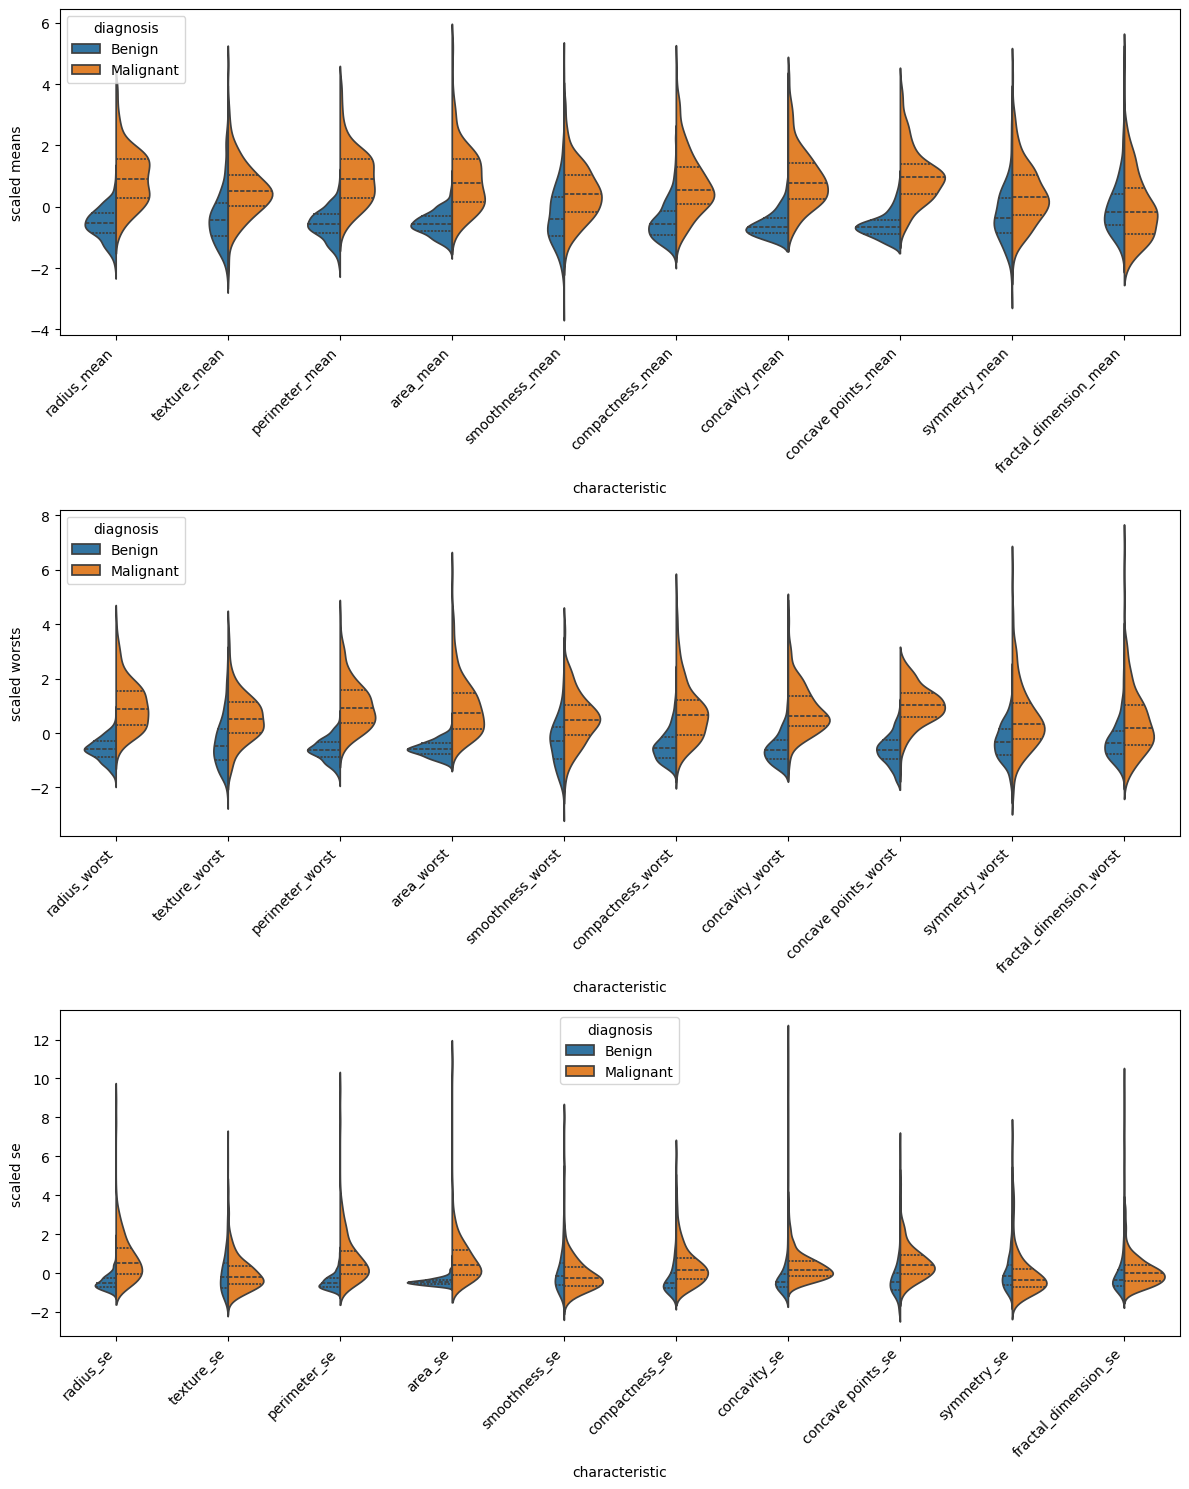

In [12]:
figs, (ax1, ax2, ax3) = plt.subplots(nrows=3, ncols=1, figsize=(12, 15))

# violin plot for means

means = df_viz_scaled.loc[:,['diagnosis'] + list(MEAN_COL_NAMES)]
long_means = means.melt(id_vars='diagnosis', var_name='characteristic', value_name='scaled means')

v_means = sns.violinplot(data=long_means, x='characteristic', y='scaled means', hue='diagnosis', split=True, ax=ax1, inner='quart', hue_order=['Benign', 'Malignant'])

# violin plot for worsts

worsts = df_viz_scaled.loc[:,['diagnosis'] + list(WORST_COL_NAMES)]
long_worsts = worsts.melt(id_vars='diagnosis', var_name='characteristic', value_name='scaled worsts')

v_worsts = sns.violinplot(data=long_worsts, x='characteristic', y='scaled worsts', hue='diagnosis', split=True, ax=ax2, inner='quart', hue_order=['Benign', 'Malignant'])

# violin plots for se

ses = df_viz_scaled.loc[:,['diagnosis'] + list(SE_COL_NAMES)]
long_ses = ses.melt(id_vars='diagnosis', var_name='characteristic', value_name='scaled se')

v_ses = sns.violinplot(data=long_ses, x='characteristic', y='scaled se', hue='diagnosis', split=True, ax=ax3, inner='quart', hue_order=['Benign', 'Malignant'])

# make x axis labels diagonal for both plots
plt.xticks(rotation=45, ha='right')

ticks_means = v_means.get_xticks()
v_means.set_xticks(ticks_means)
v_means.set_xticklabels(v_means.get_xticklabels(), rotation=45, ha='right')

ticks_worsts = v_worsts.get_xticks()
v_worsts.set_xticks(ticks_worsts)
v_worsts.set_xticklabels(v_worsts.get_xticklabels(), rotation=45, ha='right')

ticks_se = v_ses.get_xticks()
v_ses.set_xticks(ticks_se)
v_ses.set_xticklabels(v_ses.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

#### Conclusion

The violin plots allow us to visualize which features can distinguish between benign and malignant cells. In particular, fractal_dimension_mean, texture_se, and smoothness_se most clearly do not distinguish between benign and malignant cells as the peaks and means of the malignant and benign distributions line up practically perfectly. 

Features like symmetry_se, fractal_dimension_worst, fractal_dimension_se, symmetry_mean, smoothness_mean, and compactness_se also do not as clearly distinguish between malignant and benign cells compared to other features where the peaks of the benign and malignant distributions do not overlap nearly as much. For these features, we will need the Mann-Whitney U test to confirm whether they can distinguish between malignant and benign cells.

### Mann-Whitney U test

We test for a statistically significant difference between benign and malignant groups for each characteristic's mean, worst, and SE. We chose to use the Mann-Whitney U test instead of an unpaired student's t-test because while both are used for testing for statistical significance between two independent groups, the data, according to the violin plots, is not normally distributed for both malignant and benign groups and we are dealing with a relatively small dataset. (The t-test is only used for normal distributions and large datasets; Mann-Whitney if data is skewed and dataset is smaller.)

In [19]:
df_mann = df.drop(columns=['id'])
df_mann

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,1,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,1,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,1,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,1,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [1]:
# get benign group and malignant group for a characteristic's mean. put that into the u test... repeat for other characteristic's means, SEs, and worsts.

print("--- P-values for Means ---")
for col in MEAN_COL_NAMES:
    stats, pvalue = mannwhitneyu(df.loc[df['diagnosis'] == 'Benign', col], df.loc[df['diagnosis'] == 'Malignant', col])
    print(f"{col} : {pvalue}")

print("\n--- P-values for Worsts ---")
for col in WORST_COL_NAMES:
    stats, pvalue = mannwhitneyu(df.loc[df['diagnosis'] == 'Benign', col], df.loc[df['diagnosis'] == 'Malignant', col])
    print(f"{col} : {pvalue}")

print("\n--- P-values for SEs ---")
for col in SE_COL_NAMES:
    stats, pvalue = mannwhitneyu(df.loc[df['diagnosis'] == 'Benign', col], df.loc[df['diagnosis'] == 'Malignant', col])
    print(f"{col} : {pvalue}")

--- P-values for Means ---


NameError: name 'MEAN_COL_NAMES' is not defined

### Pair plot

- Round blobs of orange and blue = little/no correlation between the two features
- Blue blob distinct from orange blob: one or both features clearly distinguish between malignant and benign
    - one feature distinguishes between malignant and benign more than the other does if it's a "straight shift" (i.e. one colored blob to the left of or on top of the other colored blob)
    - both features work together to distinguish between malignant and benign if it's a "diagonal shift" (i.e. colored blobs don't overlap too much and the overall cloud of data stretches out diagonally up or down)

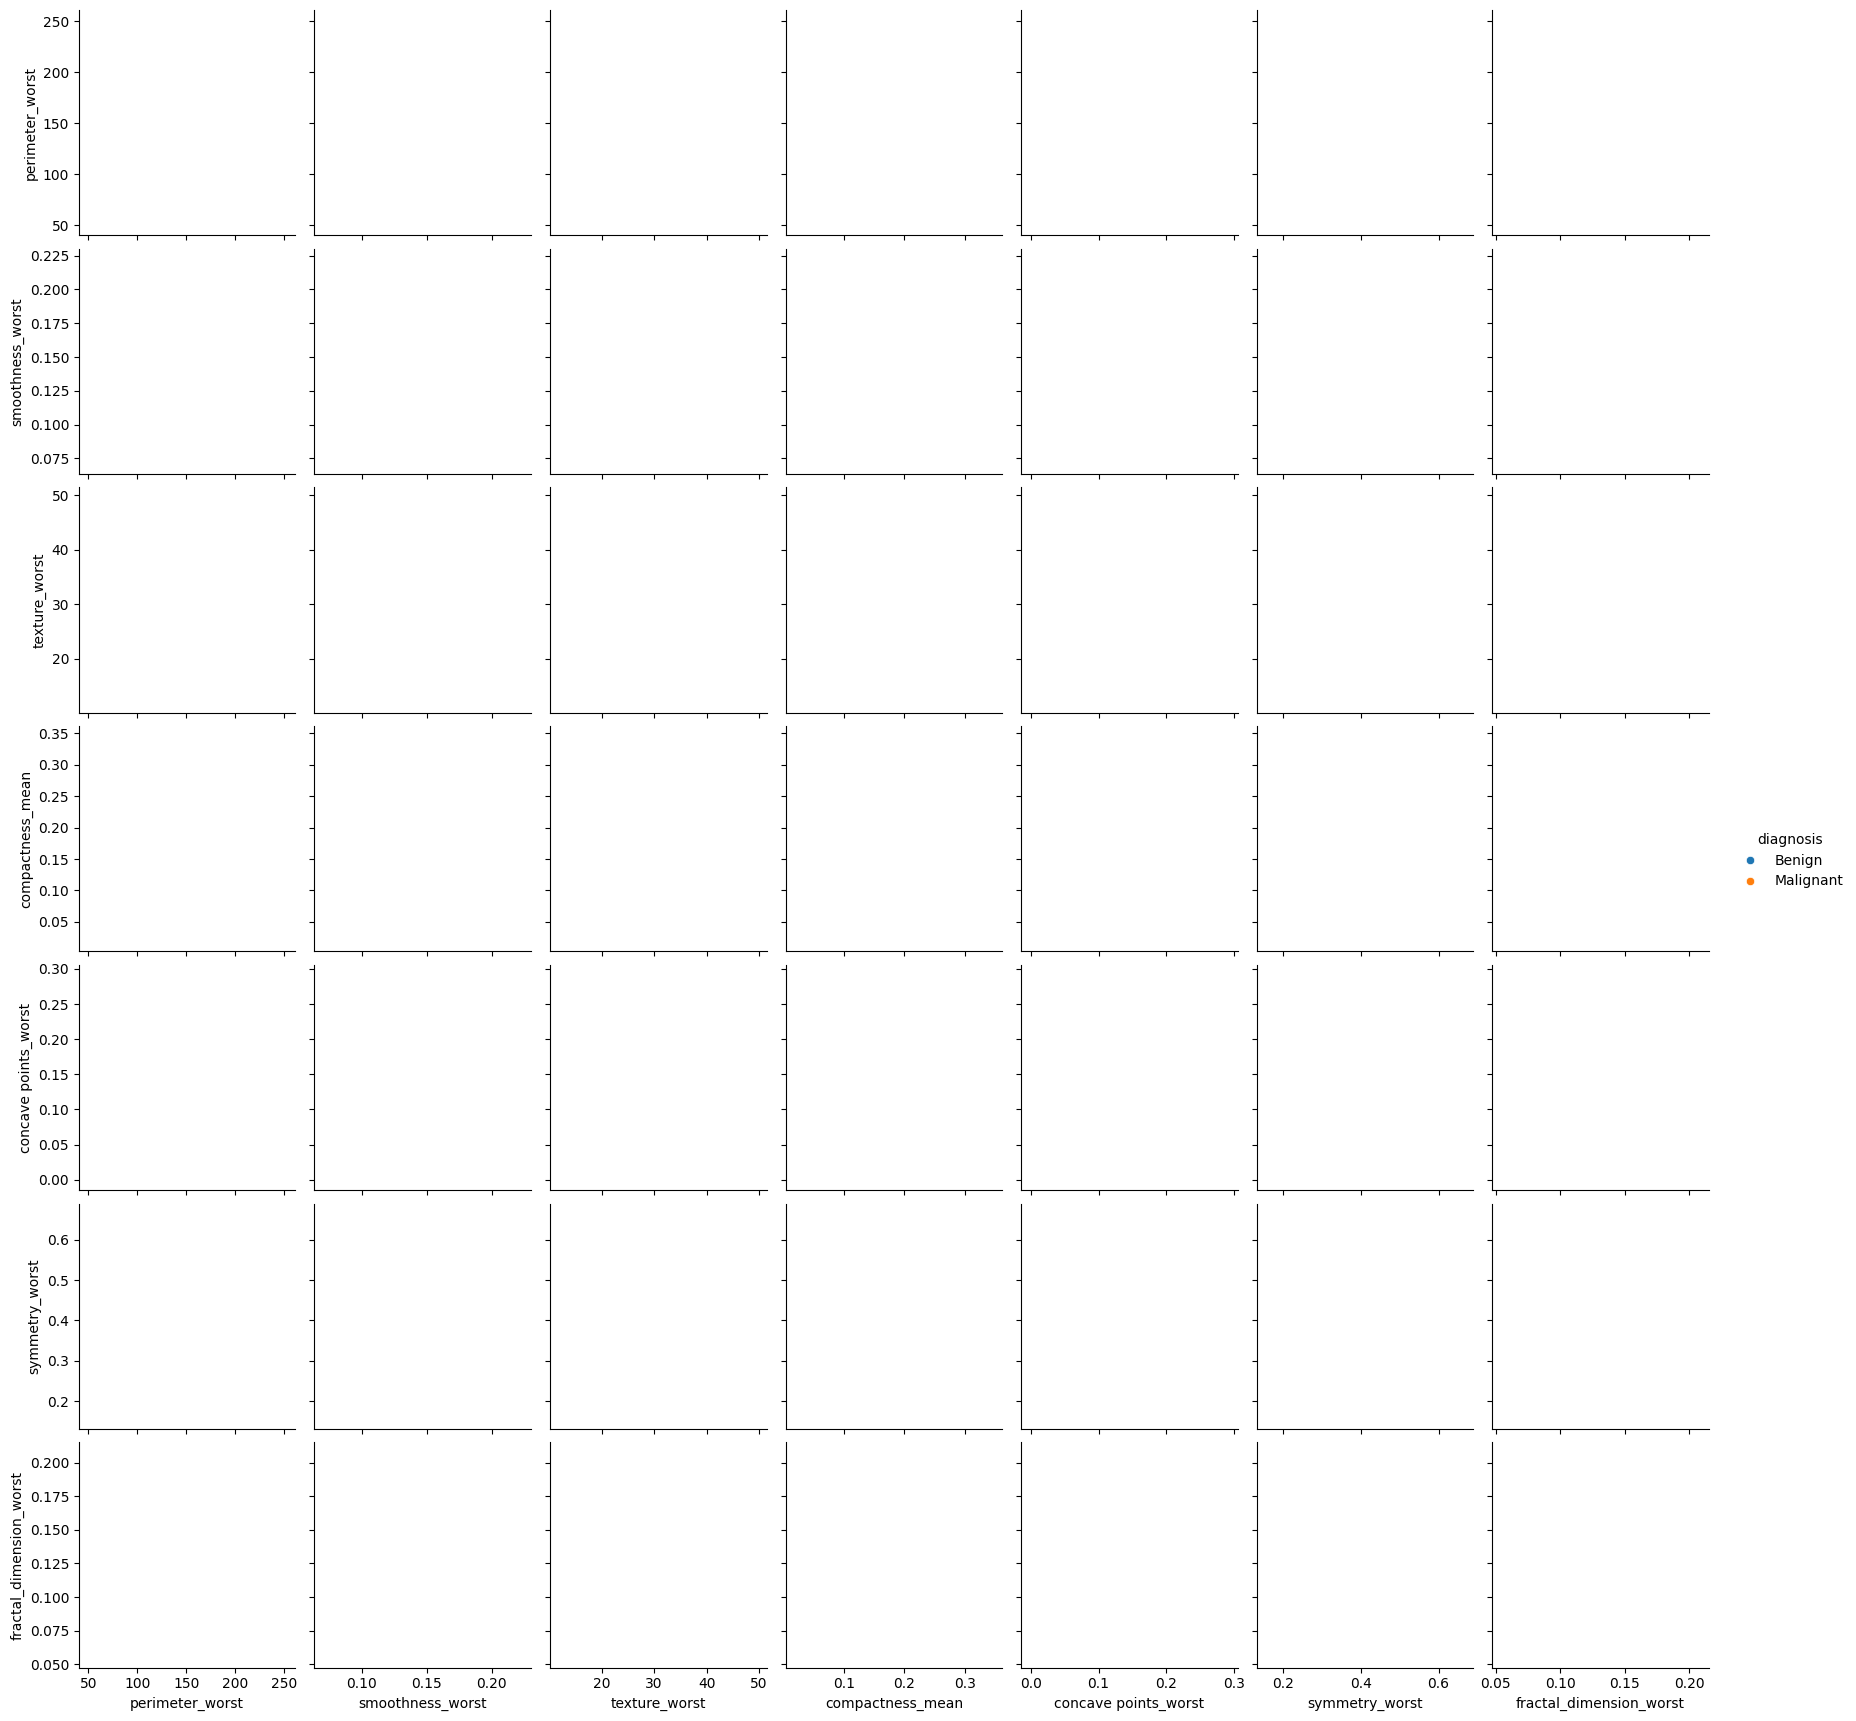

In [6]:
df_sig = df[['diagnosis', 'perimeter_worst', 'smoothness_worst', 'texture_worst', 'compactness_mean', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']]

grid = sns.pairplot(df_sig, hue='diagnosis', hue_order=['Benign', 'Malignant'])

### Class Imbalance Check (pie plot)

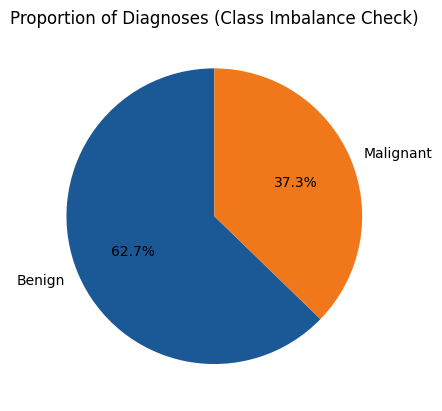

In [ ]:
diagnosis_counts = df['diagnosis'].value_counts()
plt.pie(diagnosis_counts, autopct='%1.1f%%', startangle=90, colors=['#1A5896', '#F0771A'], labels=diagnosis_counts.index)
plt.title('Proportion of Diagnoses (Class Imbalance Check)')
plt.show()

## Random Forest

### Prep data for training

#### 1. Convert diagnosis to 0s and 1s (1 = malignant, 0 = benign)

In [7]:
df['diagnosis'] = df['diagnosis'].replace({'Malignant': 1, 'Benign': 0})
df.tail()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
564,926424,1,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,1,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,1,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,1,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400
568,92751,0,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,...,9.456,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039


#### 2. Split into training and testing sets

Use stratified sampling as the target variable (diagnosis) is imbalanced (63/37) to ensure the ratio of classes remains the same in both training and testing sets. Random split might isolate one class to one set. Since dataset is small (< 1000 samples), use 80 / 20 split

In [ ]:
y = df['diagnosis'].astype(int)  # target
X = df_sig.drop(columns='diagnosis')  # unscaled features

X_train, X_test, y_train, y_test = train_test_split(X, y, 
test_size=0.2, train_size=0.8, random_state=42, stratify=y)

10     1
170    0
407    0
430    1
27     1
      ..
37     0
415    0
458    0
476    0
335    1
Name: diagnosis, Length: 455, dtype: int64

#### 3. Scale the training and test features

In [9]:
features_scaler = StandardScaler()

X_train_scaled = features_scaler.fit_transform(X_train)
X_test_scaled = features_scaler.transform(X_test)

print("--- Data Prep Verification ---")
print(f"Training Set Size: {X_train_scaled.shape[0]} samples")
print(f"Testing Set Size:  {X_test_scaled.shape[0]} samples")
print(f"Malignant ratio in Train: {y_train.mean():.1%}")
print(f"Malignant ratio in Test:  {y_test.mean():.1%}")

--- Data Prep Verification ---
Training Set Size: 455 samples
Testing Set Size:  114 samples
Malignant ratio in Train: 37.4%
Malignant ratio in Test:  36.8%


### 4. Training

In [10]:
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_model.fit(X_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### 5. Predicting

Train accuracy: 1.0000
Test accuracy: 0.9561

              precision    recall  f1-score   support

      Benign       0.94      1.00      0.97        72
   Malignant       1.00      0.88      0.94        42

    accuracy                           0.96       114
   macro avg       0.97      0.94      0.95       114
weighted avg       0.96      0.96      0.96       114



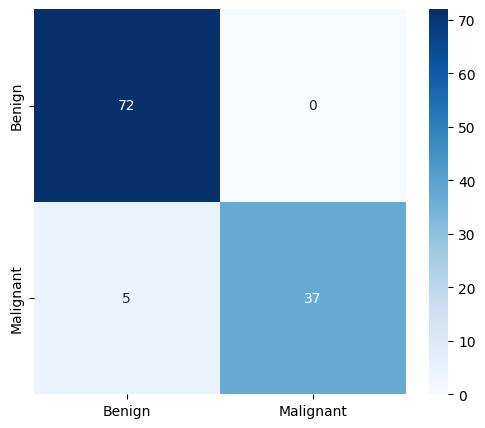

In [ ]:
# let model make predictions on test data and training data
test_preds = rf_model.predict(X_test_scaled)
train_preds = rf_model.predict(X_train_scaled)

# check for overfitting
train_acc = accuracy_score(y_train, train_preds)
test_acc = accuracy_score(y_test, test_preds)
print(f"Train accuracy: {train_acc:.4f}")
print(f"Test accuracy: {test_acc:.4f}\n")

# print confusion matrix for test set
cm = confusion_matrix(y_test, test_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, 
    annot=True,            # Put the raw numbers inside the boxes
    fmt='d',               # Format as integers (not decimals)
    cmap='Blues',          # Clean blue color gradient
    xticklabels=['Benign', 'Malignant'], 
    yticklabels=['Benign', 'Malignant']
)

# print classification report for test set
print(classification_report(y_test, test_preds, target_names=['Benign', 'Malignant']))